# Phase 4 — Machine Learning

Notebook pour exécuter la Phase 4 : 4.1 Segmentation (RFM), 4.2 Classification (churn) et 4.3 Régression (delivery_days).
Exécutez les cellules séquentiellement. Les artefacts sont sauvegardés dans `data/processed/` et `models/`.

In [6]:
# Imports et détection des chemins racine/procédés
import os
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, AdaBoostClassifier
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, confusion_matrix, silhouette_score, r2_score, mean_squared_error, mean_absolute_error)

RANDOM_STATE = 42

def find_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'db').exists():
            return candidate
    return cwd

ROOT = find_root()
PROCESSED = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
PLOTS = MODELS / 'plots'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)
os.makedirs(PLOTS, exist_ok=True)

print('Project root:', ROOT)
print('Processed dir:', PROCESSED)
print('Models dir:', MODELS)

Project root: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16- Projet_intérgration\RetailSenseAI
Processed dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16- Projet_intérgration\RetailSenseAI\data\processed
Models dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16- Projet_intérgration\RetailSenseAI\models


In [7]:
# Chargement des jeux préparés
orders_fp = PROCESSED / 'orders_features.csv'
rfm_fp = PROCESSED / 'rfm_matrix.csv'
rfm_std_fp = PROCESSED / 'rfm_standardized.csv'

assert orders_fp.exists(), f"Fichier introuvable: {orders_fp}"
assert rfm_fp.exists(), f"Fichier introuvable: {rfm_fp}"

orders = pd.read_csv(orders_fp)
rfm = pd.read_csv(rfm_fp)
rfm_std = pd.read_csv(rfm_std_fp) if rfm_std_fp.exists() else None

print('orders shape:', orders.shape)
print('rfm shape:', rfm.shape)
if rfm_std is not None:
    print('rfm_standardized shape:', rfm_std.shape)

orders shape: (99441, 24)
rfm shape: (96096, 4)
rfm_standardized shape: (96096, 3)


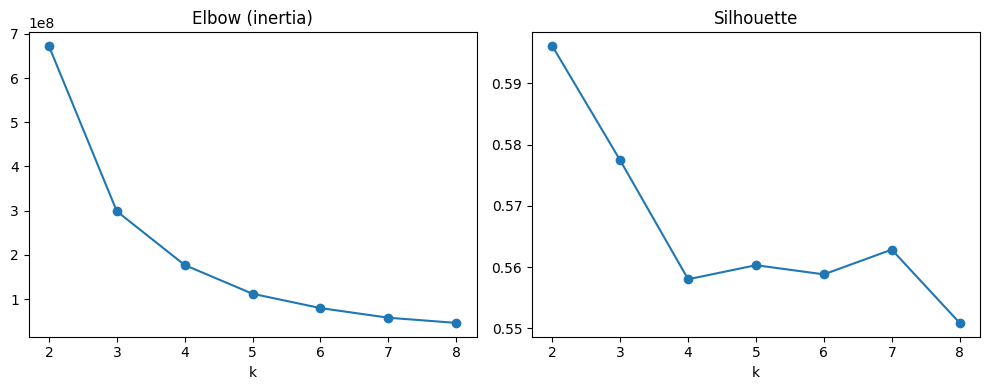

KMeans silhouette: 0.5580067715459214
Saved rfm_segments.csv and kmeans_rfm.joblib


In [8]:
# 4.1 Segmentation RFM — elbow + silhouette, KMeans et DBSCAN
if rfm_std is not None:
    X = rfm_std[['recency','frequency','monetary']].astype(float).values
else:
    X = rfm[['recency','frequency','monetary']].copy()
    X['monetary'] = np.log1p(X['monetary'])
    X['frequency'] = np.log1p(X['frequency'])
    X = StandardScaler().fit_transform(X)

# elbow and silhouette
inertias = []
scores = []
ks = list(range(2,9))
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, '-o')
plt.title('Elbow (inertia)')
plt.xlabel('k')
plt.subplot(1,2,2)
plt.plot(ks, scores, '-o')
plt.title('Silhouette')
plt.xlabel('k')
plt.tight_layout()
plt.savefig(PLOTS / 'rfm_elbow_silhouette.png')
plt.show()

chosen_k = 4
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10).fit(X)
labels_k = kmeans.labels_
sil_score = silhouette_score(X, labels_k)

db = DBSCAN(eps=0.5, min_samples=5).fit(X)
labels_db = db.labels_

rfm_out = rfm.copy()
rfm_out['kmeans_label'] = labels_k
rfm_out['dbscan_label'] = labels_db
rfm_out.to_csv(PROCESSED / 'rfm_segments.csv', index=False)
joblib.dump(kmeans, MODELS / 'kmeans_rfm.joblib')

print('KMeans silhouette:', sil_score)
print('Saved rfm_segments.csv and kmeans_rfm.joblib')

## 4.2 Classification (churn)

Ce bloc prépare le jeu de données de classification `bad_review` avec les variables prescrites par le guide.

In [9]:
# Préparation classification
df = orders.copy()
target = 'bad_review'
df = df[df[target].notna()]
df[target] = df[target].astype(int)

feature_cols = [
    'total_price', 'total_freight', 'total_weight', 'n_items',
    'max_installments', 'payment_value', 'delivery_days', 'delay_days',
    'purchase_month', 'purchase_dow', 'main_category', 'payment_type',
    'customer_state'
]
missing = [c for c in feature_cols if c not in df.columns]
assert not missing, f"Missing expected feature columns: {missing}"
X_cls = df[feature_cols].copy()
y_cls = df[target]

X_trainval, X_test, y_trainval, y_test = train_test_split(X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category','bool']).columns.tolist()

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor_cls = ColumnTransformer([('num', numeric_transformer, numeric_cols), ('cat', categorical_transformer, categorical_cols)], remainder='drop')

classification_results = {}

print('Classification dataset prepared with', len(X_train), 'training rows and', len(X_test), 'test rows.')

Classification dataset prepared with 59203 training rows and 19735 test rows.


In [10]:
# Logistic Regression
logistic_pipe = Pipeline([('pre', preprocessor_cls), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])
logistic_pipe.fit(X_train, y_train)
y_val_pred = logistic_pipe.predict(X_val)
logistic_f1 = f1_score(y_val, y_val_pred)

classification_results['logistic'] = {'model': logistic_pipe, 'f1': logistic_f1}
joblib.dump(logistic_pipe, MODELS / 'churn_logistic.joblib')
print('Logistic Regression validation F1:', logistic_f1)

Logistic Regression validation F1: 0.37525963535656587


In [11]:
# Decision Tree
dt_pipe = Pipeline([('pre', preprocessor_cls), ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))])
dt_pipe.fit(X_train, y_train)
y_val_pred = dt_pipe.predict(X_val)
dt_f1 = f1_score(y_val, y_val_pred)

classification_results['decision_tree'] = {'model': dt_pipe, 'f1': dt_f1}
joblib.dump(dt_pipe, MODELS / 'churn_decision_tree.joblib')
print('Decision Tree validation F1:', dt_f1)

Decision Tree validation F1: 0.3876123876123876


In [12]:
# AdaBoost
ada_pipe = Pipeline([('pre', preprocessor_cls), ('clf', AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE))])
ada_pipe.fit(X_train, y_train)
y_val_pred = ada_pipe.predict(X_val)
ada_f1 = f1_score(y_val, y_val_pred)

classification_results['adaboost'] = {'model': ada_pipe, 'f1': ada_f1}
joblib.dump(ada_pipe, MODELS / 'churn_adaboost.joblib')
print('AdaBoost validation F1:', ada_f1)

AdaBoost validation F1: 0.40089641434262946


In [13]:
# Random Forest with GridSearchCV
rf_pipe = Pipeline([('pre', preprocessor_cls), ('clf', RandomForestClassifier(random_state=RANDOM_STATE))])
rf_param = {'clf__n_estimators':[100,200], 'clf__max_depth':[3,10], 'clf__class_weight':['balanced','balanced_subsample']}
rf_grid = GridSearchCV(rf_pipe, rf_param, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_val_pred = rf_best.predict(X_val)
rf_f1 = f1_score(y_val, y_val_pred)

classification_results['random_forest'] = {'model': rf_best, 'f1': rf_f1}
joblib.dump(rf_best, MODELS / 'churn_random_forest.joblib')
print('Random Forest validation F1:', rf_f1)

Random Forest validation F1: 0.4779512047279891


In [14]:
# Gradient Boosting with GridSearchCV
gb_pipe = Pipeline([('pre', preprocessor_cls), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_param = {'clf__n_estimators':[100,200], 'clf__learning_rate':[0.05,0.1], 'clf__max_depth':[3,5]}
gb_grid = GridSearchCV(gb_pipe, gb_param, cv=3, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_
y_val_pred = gb_best.predict(X_val)
gb_f1 = f1_score(y_val, y_val_pred)

classification_results['gradient_boost'] = {'model': gb_best, 'f1': gb_f1}
joblib.dump(gb_best, MODELS / 'churn_gradient_boost.joblib')
print('Gradient Boosting validation F1:', gb_f1)

Gradient Boosting validation F1: 0.5087404751232631


In [15]:
# Évaluation finale classification et sauvegarde des métriques
best_name = max(classification_results, key=lambda name: classification_results[name]['f1'])
best_model = classification_results[best_name]['model']
y_test_pred = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred)

summary = []
for name, result in classification_results.items():
    summary.append({'model': name, 'val_f1': result['f1']})
summary_df = pd.DataFrame(summary)
summary_df.to_csv(MODELS / 'churn_metrics_summary.csv', index=False)
joblib.dump(best_model, MODELS / 'churn_best.joblib')
print('Best classification model:', best_name, 'val_f1=', classification_results[best_name]['f1'], 'test_f1=', test_f1)
print('Saved classification models and metrics in', MODELS)

Best classification model: gradient_boost val_f1= 0.5087404751232631 test_f1= 0.49886928991406604
Saved classification models and metrics in E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16- Projet_intérgration\RetailSenseAI\models


## 4.3 Régression (delivery_days)

Ce bloc prépare le jeu de données de régression et entraîne un baseline linéaire, un RandomForest et un GradientBoosting.

In [16]:
# Préparation régression
df_reg = orders.copy()
df_reg = df_reg[df_reg['delivery_days'].notna()]
target_reg = 'delivery_days'

feature_cols_reg = [
    'total_price', 'total_freight', 'total_weight', 'n_items',
    'payment_value', 'purchase_month', 'main_category', 'customer_state'
]
missing_reg = [c for c in feature_cols_reg if c not in df_reg.columns]
assert not missing_reg, f"Missing expected regression feature columns: {missing_reg}"
X_reg = df_reg[feature_cols_reg].copy()
y_reg = df_reg[target_reg]

X_trainval_reg, X_test_reg, y_trainval_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X_trainval_reg, y_trainval_reg, test_size=0.25, random_state=RANDOM_STATE)

numeric_cols_reg = X_train_reg.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols_reg = X_train_reg.select_dtypes(include=['object','category','bool']).columns.tolist()

numeric_transformer_reg = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer_reg = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32))])
preprocessor_reg = ColumnTransformer([('num', numeric_transformer_reg, numeric_cols_reg), ('cat', categorical_transformer_reg, categorical_cols_reg)], remainder='drop')

regression_results = {}
print('Regression dataset prepared with', len(X_train_reg), 'training rows and', len(X_test_reg), 'test rows.')

Regression dataset prepared with 57885 training rows and 19296 test rows.


In [17]:
# Linear Regression baseline
lin_pipe = Pipeline([('pre', preprocessor_reg), ('reg', LinearRegression())])
lin_pipe.fit(X_train_reg, y_train_reg)
y_val_pred = lin_pipe.predict(X_val_reg)
lin_mae = mean_absolute_error(y_val_reg, y_val_pred)
regression_results['linear'] = {'model': lin_pipe, 'mae': lin_mae}
joblib.dump(lin_pipe, MODELS / 'delivery_linear.joblib')
print('Linear Regression validation MAE:', lin_mae)

Linear Regression validation MAE: 5.546986883740076


In [18]:
# Random Forest regression with GridSearchCV
rf_pipe_reg = Pipeline([('pre', preprocessor_reg), ('reg', RandomForestRegressor(random_state=RANDOM_STATE))])
rf_param_reg = {'reg__n_estimators':[100,200], 'reg__max_depth':[3,10]}
rf_grid_reg = GridSearchCV(rf_pipe_reg, rf_param_reg, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid_reg.fit(X_train_reg, y_train_reg)
rf_best_reg = rf_grid_reg.best_estimator_
y_val_pred = rf_best_reg.predict(X_val_reg)
rf_mae = mean_absolute_error(y_val_reg, y_val_pred)
regression_results['random_forest'] = {'model': rf_best_reg, 'mae': rf_mae}
joblib.dump(rf_best_reg, MODELS / 'delivery_random_forest.joblib')
print('Random Forest validation MAE:', rf_mae)

Random Forest validation MAE: 5.081960907489309


In [19]:
# Gradient Boosting regression with GridSearchCV
gb_pipe_reg = Pipeline([('pre', preprocessor_reg), ('reg', GradientBoostingRegressor(random_state=RANDOM_STATE))])
gb_param_reg = {'reg__n_estimators':[100,200], 'reg__learning_rate':[0.05,0.1], 'reg__max_depth':[3,5]}
gb_grid_reg = GridSearchCV(gb_pipe_reg, gb_param_reg, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
gb_grid_reg.fit(X_train_reg, y_train_reg)
gb_best_reg = gb_grid_reg.best_estimator_
y_val_pred = gb_best_reg.predict(X_val_reg)
gb_mae = mean_absolute_error(y_val_reg, y_val_pred)
regression_results['gradient_boost'] = {'model': gb_best_reg, 'mae': gb_mae}
joblib.dump(gb_best_reg, MODELS / 'delivery_gradient_boost.joblib')
print('Gradient Boosting validation MAE:', gb_mae)

Gradient Boosting validation MAE: 4.96701521591452


In [20]:
# Évaluation finale régression et sauvegarde des métriques
best_reg_name = min(regression_results, key=lambda name: regression_results[name]['mae'])
best_reg_model = regression_results[best_reg_name]['model']
y_test_pred = best_reg_model.predict(X_test_reg)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)

summary_reg = []
for name, result in regression_results.items():
    summary_reg.append({'model': name, 'val_mae': result['mae']})
pd.DataFrame(summary_reg).to_csv(MODELS / 'delivery_metrics_summary.csv', index=False)
joblib.dump(best_reg_model, MODELS / 'delivery_best.joblib')
print('Best regression model:', best_reg_name, 'val_mae=', regression_results[best_reg_name]['mae'], 'test_mae=', test_mae)
print('Saved regression models and metrics in', MODELS)

Best regression model: gradient_boost val_mae= 4.96701521591452 test_mae= 4.948701625482231
Saved regression models and metrics in E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16- Projet_intérgration\RetailSenseAI\models
